<a href="https://colab.research.google.com/github/AnushikaTripathi9102006/Summer-training-/blob/main/Copy_of_2_outliers_z_score_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 align='center' style='color:blue'>Exercise: Outlier removal using standard deviation and z score<h2>

You are given bhp.csv which contains property prices in the city of banglore, India. You need to examine price_per_sqft column and do following,

(1) Remove outliers using percentile technique first. Use [0.001, 0.999] for lower and upper bound percentiles

(2) After removing outliers in step 1, you get a new dataframe.

(3) On step(2) dataframe, use 4 standard deviation to remove outliers

(4) Plot histogram for new dataframe that is generated after step (3). Also plot bell curve on same histogram

(5) On step(2) dataframe, use zscore of 4 to remove outliers. This is quite similar to step (3) and you will get exact same result

In [ ]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

In [ ]:
df = pd.read_csv("/content/bhp.csv")
df.head()#The head() function displays the first 5 rows of the DataFrame by default.It gives us a quick preview of the dataset.



,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


We will quickly examine price_per_sqft column to check min,max,mean and percentile values

In [ ]:
# This statistical summary helps us decide whether outlier removal is necessary.
df.price_per_sqft.describe() #.describe() function calculates several useful statistical measures automatically

,price_per_sqft
count,1.320000e+04
mean,7.920337e+03
std,1.067272e+05
min,2.670000e+02
25%,4.267000e+03
50%,5.438000e+03
75%,7.317000e+03
max,1.200000e+07


Above, you can see max is 12000000, which is too much price for price per sqft. Looks like this dataset has some very bad outliers so we will first remove those with percentile and then use z score

Also **plot histogram** to see how is the data distribution

A histogram provides a visual representation of the data.

This helps us answer questions like:

Are most values clustered together?
Are there any extreme values?
Is the data normally distributed?
Is the distribution skewed?

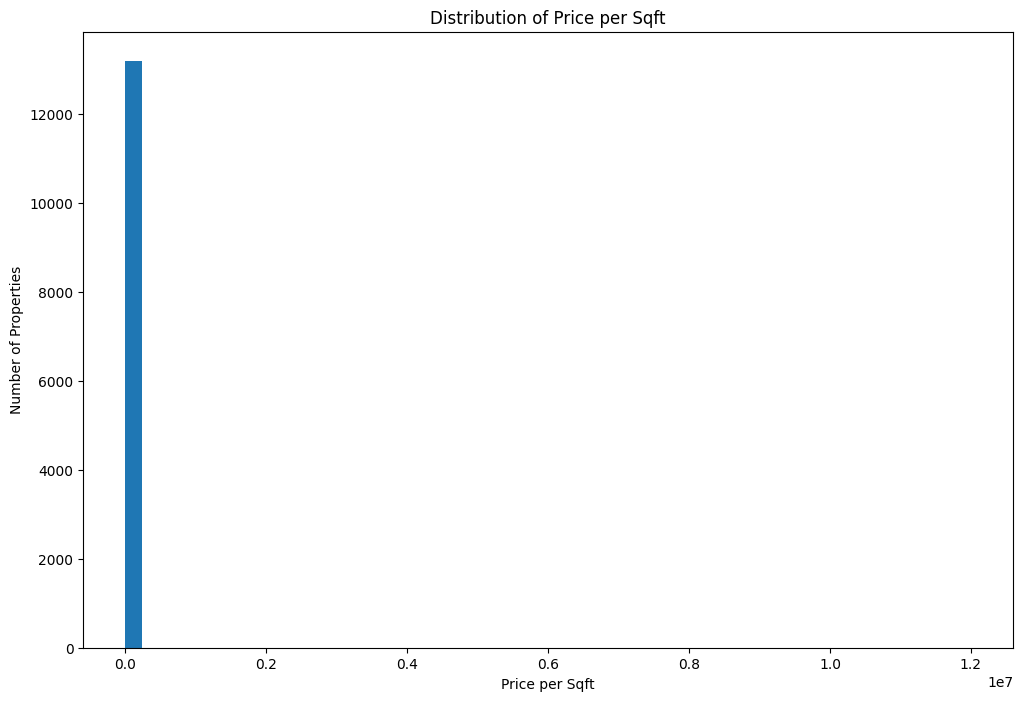

In [ ]:
plt.hist(df.price_per_sqft, bins=50)
plt.xlabel("Price per Sqft")
plt.ylabel("Number of Properties")
plt.title("Distribution of Price per Sqft")
plt.show()

Above chart confirms our understanding that this dataset has some bad outliers. Because we see only one bar with more than 12000 data points but on the right hand side there are data points that have higher value for price per sqft but count of these data points is very tiny compared to 12000 hence we can hardly see any bar

Using **log scale** can make visualization little better

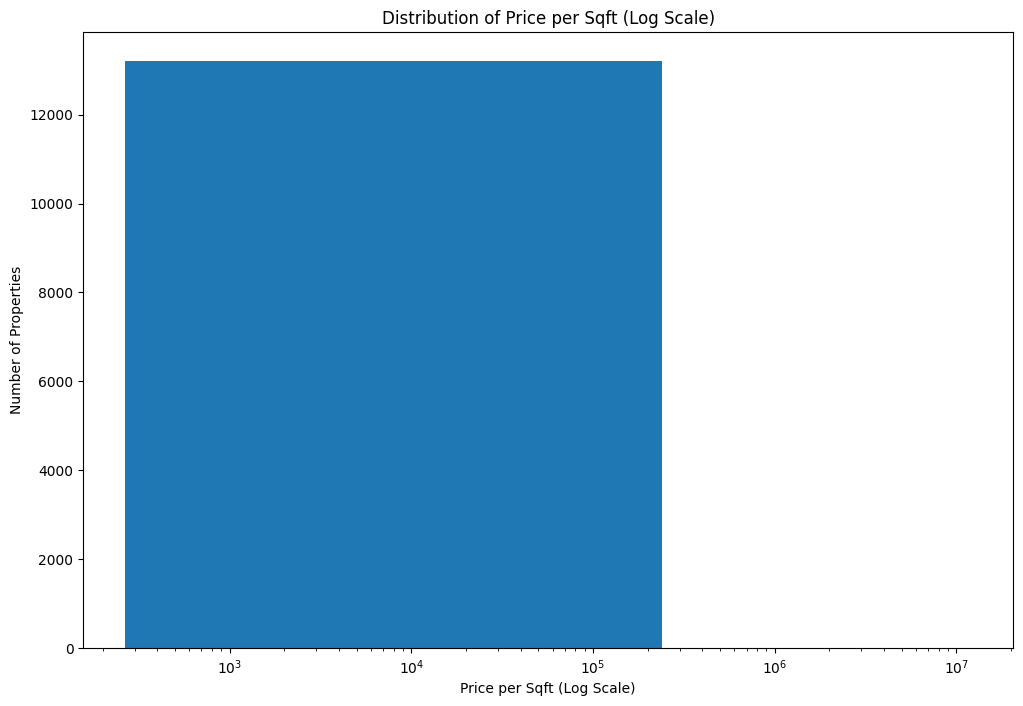

In [ ]:
plt.hist(df.price_per_sqft, bins=50)
plt.xscale('log')

plt.xlabel("Price per Sqft (Log Scale)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Price per Sqft (Log Scale)")

plt.show()

You see atleast few bars on right hand side of our highest building at least :)

<h3 style='color:purple'>(1) Treat outliers using percentile first</h3>

In [ ]:
lower_limit = df.price_per_sqft.quantile(0.001)
upper_limit = df.price_per_sqft.quantile(0.999)

print(lower_limit, upper_limit)

1366.184 50959.36200000098


In [ ]:
# Display rows that are outside the percentile limits
df[
    (df.price_per_sqft < lower_limit) |
    (df.price_per_sqft > upper_limit)
]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
665,Yelahanka,3 BHK,35000.0,3.0,130.0,3,371
798,other,4 Bedroom,10961.0,4.0,80.0,4,729
1005,other,1 BHK,15.0,1.0,30.0,1,200000
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000
1867,other,3 Bedroom,52272.0,2.0,140.0,3,267
2392,other,4 Bedroom,2000.0,3.0,25.0,4,1250
3934,other,1 BHK,1500.0,1.0,19.5,1,1300
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
4924,other,7 BHK,5.0,7.0,115.0,7,2300000


Above shows properties that has price_per_sqft value such as 500 rs which is very very low for the city of banglore. You would be very lucky if you can find such as property :)
Also we have properties that has price per sqft value such as 12000000 which is way too high. It seems almost impossible and even if it is legitimate it can help data analysis process if we remove such a data point

In [ ]:
# Create a new DataFrame after removing percentile outliers
df2 = df[
    (df.price_per_sqft >= lower_limit) &
    (df.price_per_sqft <= upper_limit)
]

# Display the shape of the new DataFrame
df2.shape

(13172, 7)

In [ ]:
df.shape

(13200, 7)

In [ ]:
# Number of rows removed after percentile filtering
print(df.shape[0] - df2.shape[0])

28


**We removed total 28 outliers**

<h3 style='color:purple'>(2) Now remove outliers using 4 standard deviation</h3>

In [ ]:
# Calculate mean and standard deviation
mean = df2.price_per_sqft.mean()
std = df2.price_per_sqft.std()

# Calculate lower and upper limits using 4 standard deviations
upper_limit = mean + 4 * std
lower_limit = mean - 4 * std

print(upper_limit, lower_limit)

23227.73653589429 -9900.429065502549


In [ ]:
# Display outliers based on 4 standard deviations
df2[
    (df2.price_per_sqft > upper_limit) |
    (df2.price_per_sqft < lower_limit)
]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333
190,Bellandur,4 Bedroom,1200.0,5.0,325.0,4,27083
733,Cunningham Road,4 BHK,5270.0,4.0,1250.0,4,23719
760,other,9 Bedroom,600.0,9.0,190.0,9,31666
...,...,...,...,...,...,...,...
13081,other,6 Bedroom,8000.0,6.0,2800.0,6,35000
13094,other,4 Bedroom,1200.0,5.0,325.0,4,27083
13127,other,4 Bedroom,1200.0,5.0,325.0,4,27083
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000


In [ ]:
# Remove outliers using 4 standard deviation rule
df3 = df2[
    (df2.price_per_sqft <= upper_limit) &
    (df2.price_per_sqft >= lower_limit)
]

# Display the shape of the new DataFrame
df3.shape

(13047, 7)

In [ ]:
# Number of rows removed after applying the 4 standard deviation rule
print(df2.shape[0] - df3.shape[0])

125


In this step we removed total 125 outliers

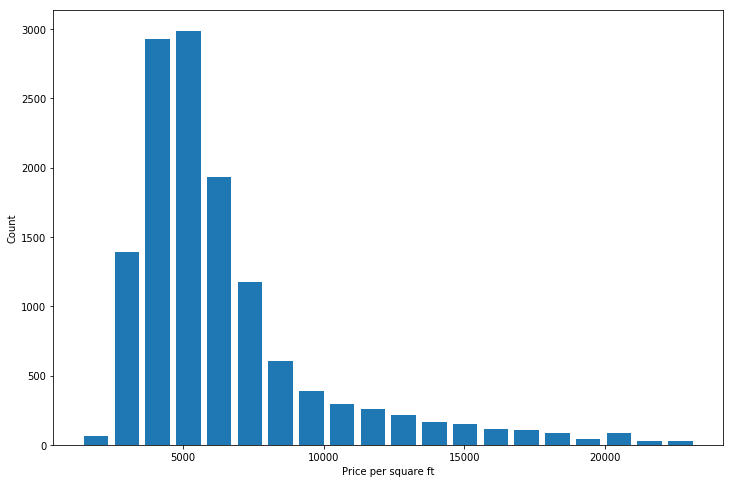

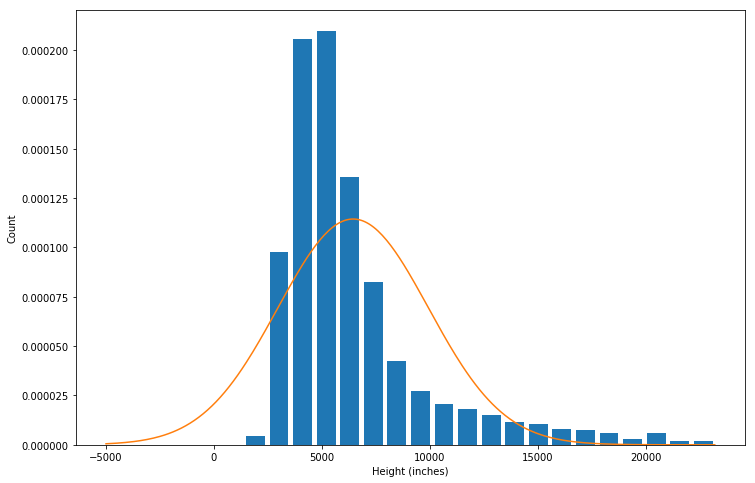

<h3 style='color:purple'>(3) Now remove outliers using z score. Use z score of 4 as your thresold</h3>

In [ ]:
from scipy.stats import zscore

# Calculate Z-score for each row
df2['zscore'] = zscore(df2.price_per_sqft)

# Display first few rows
df2.head()

/tmp/ipykernel_4705/1732717310.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zscore'] = zscore(df2.price_per_sqft)


,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.715951
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.494741
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.569604
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.101103
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.582887


In [ ]:
# Display all outliers based on Z-score
df2[df2['zscore'].abs() > 4]
df2[df2['zscore'].abs() > 4].shape

(125, 8)

In [ ]:
df2[df2['zscore'].abs() > 4]

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274,7.150766
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333,6.440528
190,Bellandur,4 Bedroom,1200.0,5.0,325.0,4,27083,4.931181
733,Cunningham Road,4 BHK,5270.0,4.0,1250.0,4,23719,4.118790
760,other,9 Bedroom,600.0,9.0,190.0,9,31666,6.037955
...,...,...,...,...,...,...,...,...
13081,other,6 Bedroom,8000.0,6.0,2800.0,6,35000,6.843101
13094,other,4 Bedroom,1200.0,5.0,325.0,4,27083,4.931181
13127,other,4 Bedroom,1200.0,5.0,325.0,4,27083,4.931181
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000,9.016560


In [ ]:
# Remove outliers using Z-score
df4 = df2[df2['zscore'].abs() <= 4]

# Display the shape of the cleaned DataFrame
df4.shape

(13047, 8)

In [ ]:
# Number of rows removed after applying the Z-score method
print(df2.shape[0] - df4.shape[0])

125


In this step also we removed 125 outliers. The result would be exactly same as 4 standard deviation